In [1]:
import pandas as pd
import numpy as np

# Seed set kar rahe hain taaki data har baar same generate ho
np.random.seed(42)
n_samples = 5000

# Synthetic Data Generation
data = {
    'Customer_ID': np.arange(1001, 1001 + n_samples),
    'Age': np.random.randint(18, 70, size=n_samples),
    'Annual_Income_k$': np.random.randint(15, 150, size=n_samples),
    'Total_Spend_k$': np.random.randint(1, 25, size=n_samples),
    'Purchase_Frequency_Per_Month': np.random.randint(1, 15, size=n_samples),
    'Transaction_Amount': np.random.uniform(5, 2000, size=n_samples),
    'Login_Attempts': np.random.randint(1, 6, size=n_samples)
}

df = pd.DataFrame(data)

# Fraud Logic (Janbujhkar pattern daal rahe hain taaki ML ise seekh sake)
# Agar login attempts zyada hain aur transaction amount bada hai, toh fraud ke chances zyada hain
df['Is_Fraud'] = np.where((df['Transaction_Amount'] > 1200) & (df['Login_Attempts'] >= 4), 1, 0)
# Thoda random noise add karte hain fraud mein
noise = np.random.choice([0, 1], size=n_samples, p=[0.97, 0.03])
df['Is_Fraud'] = df['Is_Fraud'] | noise

# Dataset ko save karna
df.to_csv('ecommerce_customer_data.csv', index=False)
print("Dataset Successfully Created! Total Rows:", len(df))
df.head()

Dataset Successfully Created! Total Rows: 5000


,Customer_ID,Age,Annual_Income_k$,Total_Spend_k$,Purchase_Frequency_Per_Month,Transaction_Amount,Login_Attempts,Is_Fraud
0,1001,56,143,15,6,1149.576484,2,0
1,1002,69,87,12,2,1154.625324,3,0
2,1003,46,60,5,8,1904.713384,5,1
3,1004,32,120,5,11,887.928759,3,0
4,1005,60,46,18,3,1383.161210,2,0


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clustering ke liye features select karna
features_for_clustering = ['Annual_Income_k$', 'Total_Spend_k$']
X_clustering = df[features_for_clustering]

# 2. Data Scaling (Standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 3. K-Means Model Initialize aur Train karna (Hum 4 clusters bana rahe hain)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Customer_Cluster'] = kmeans.fit_transform(X_scaled).argmin(axis=1) # ya direct fit_predict

# Cluster Centers ko wapas scale back karna taaki samajh sakein
print("--- Customer Segments Successfully Created! ---")
df['Customer_Cluster'].value_counts()

--- Customer Segments Successfully Created! ---


Customer_Cluster
0    1352
2    1231
3    1225
1    1192
Name: count, dtype: int64

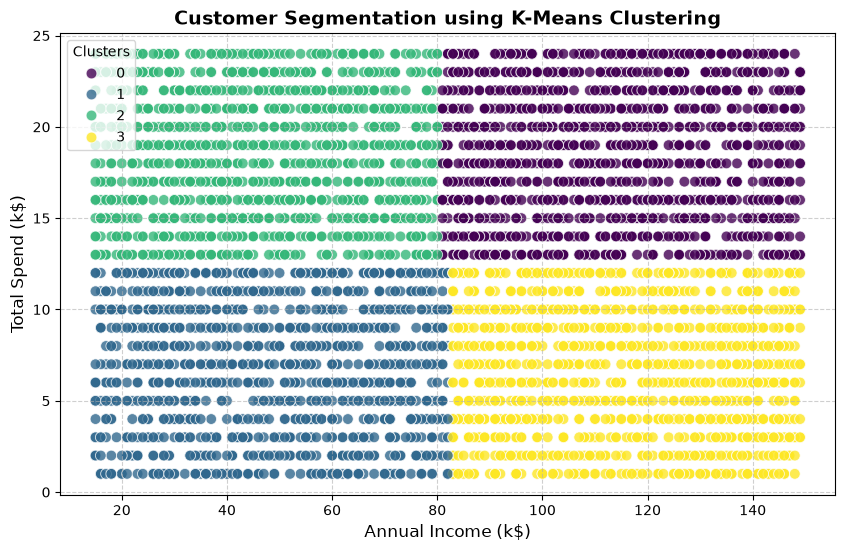

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Annual_Income_k$', 
    y='Total_Spend_k$', 
    hue='Customer_Cluster', 
    palette='viridis', 
    data=df, 
    s=60, 
    alpha=0.8
)
plt.title('Customer Segmentation using K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Total Spend (k$)', fontsize=12)
plt.legend(title='Clusters')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('customer_clusters.png') # Document ke liye save kar rahe hain
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Features (X) aur Target Variable (y) select karna
# Hum login attempts, age, transaction amount, income wagera ko features banayenge
features_for_fraud = ['Age', 'Annual_Income_k$', 'Total_Spend_k$', 
                      'Purchase_Frequency_Per_Month', 'Transaction_Amount', 'Login_Attempts']

X_fraud = df[features_for_fraud]
y_fraud = df['Is_Fraud']

# 2. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_fraud, y_fraud, test_size=0.2, random_state=42)

# 3. XGBoost Model Initialize aur Train karna
xgb_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# 4. Predictions nikalna
y_pred = xgb_model.predict(X_test)

print("--- XGBoost Fraud Model Trained Successfully! ---")

--- XGBoost Fraud Model Trained Successfully! ---


In [5]:
# Performance Report Print karna
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Feature Importance Check karna (Kaun sa feature fraud pakadne mein sabsay bada role play kar raha hai)
importance = xgb_model.feature_importances_
for i, v in enumerate(importance):
    print(f'Feature: {features_for_fraud[i]}, Score: {v:.4f}')

Confusion Matrix:
 [[800   0]
 [ 20 180]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       800
           1       1.00      0.90      0.95       200

    accuracy                           0.98      1000
   macro avg       0.99      0.95      0.97      1000
weighted avg       0.98      0.98      0.98      1000

Feature: Age, Score: 0.0164
Feature: Annual_Income_k$, Score: 0.0176
Feature: Total_Spend_k$, Score: 0.0182
Feature: Purchase_Frequency_Per_Month, Score: 0.0158
Feature: Transaction_Amount, Score: 0.1771
Feature: Login_Attempts, Score: 0.7549
